In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

# modern theme
sns.set_theme(style="whitegrid")

# nicer default size for slides
plt.rcParams["figure.figsize"] = (10,6)

# bigger fonts for presentations
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13
})

df = pd.read_excel("Azul_Project_Data.xlsx")

In [2]:
# Fuel efficiency
df["Fuel_per_NM"] = df["TripFuelBurnTotal [KG]"] / df["GroundDistance [NM]"]

# Most common routes
routes = df.groupby(["DepartureStation","ArrivalStation"]).size().sort_values(ascending=False)
top_routes = routes.head(10).index

top_eff = (
    df.set_index(["DepartureStation","ArrivalStation"])
    .loc[top_routes]
    .groupby(["DepartureStation","ArrivalStation"])["Fuel_per_NM"]
    .mean()
)

print("Average efficiency of most common routes")
print(top_eff)

# Worst efficiency routes
worst_routes = (
    df.groupby(["DepartureStation","ArrivalStation"])["Fuel_per_NM"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

Average efficiency of most common routes
DepartureStation  ArrivalStation
CGH               CNF               5.998599
CNF               CGH               6.426140
CWB               VCP               6.323199
GRU               REC               5.431612
REC               CNF               5.325658
                  GRU               6.068592
                  VCP               6.031306
SDU               VCP               6.766221
VCP               CNF               5.782075
                  REC               5.404650
Name: Fuel_per_NM, dtype: float64


        FlightNumber  TripFuelBurnTotal [KG]  TakeOffWeight  [KG]  \
count  288337.000000           288337.000000        288337.000000   
mean     4112.627661             2851.710655         48665.172350   
std      1426.950699             2164.005521         19463.353804   
min      2000.000000           -37110.000000         14838.000000   
25%      2872.000000             1011.000000         22372.000000   
50%      4205.000000             2158.000000         52276.000000   
75%      4577.000000             4378.000000         65959.000000   
max      9914.000000            16413.000000         88992.000000   

         TripTimeSec  GroundDistance [NM]    Fuel_per_NM   Fuel_per_sec  
count  288337.000000        288337.000000  288337.000000  288337.000000  
mean     5490.362388           556.129955       4.910821       0.480508  
std      2942.360548           390.701359       1.406607       0.237098  
min     -5220.000000            16.000000     -68.569845      -6.949438  
25%     

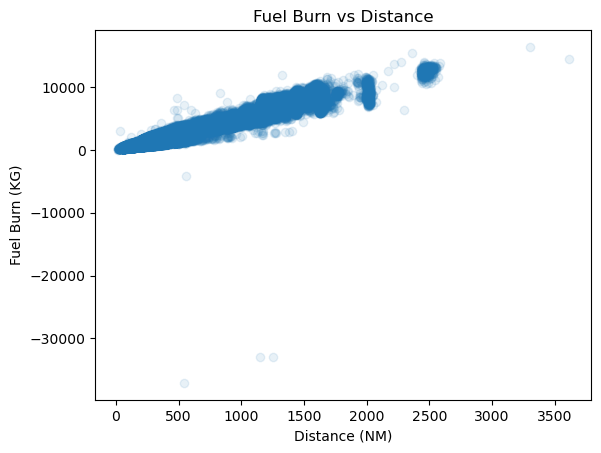

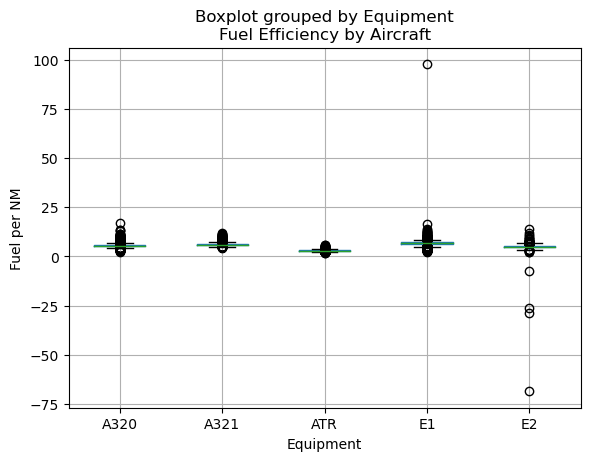

In [4]:
# Derived efficiency metrics
df["Fuel_per_NM"] = df["TripFuelBurnTotal [KG]"] / df["GroundDistance [NM]"]
df["Fuel_per_sec"] = df["TripFuelBurnTotal [KG]"] / df["TripTimeSec"]

# Basic summary statistics
print(df.describe())

# Correlation analysis
corr = df[[
    "TripFuelBurnTotal [KG]",
    "TakeOffWeight  [KG]",
    "TripTimeSec",
    "GroundDistance [NM]",
    "Fuel_per_NM"
]].corr()

print("\nCorrelation Matrix")
print(corr)

# Fuel efficiency by aircraft
fuel_by_aircraft = df.groupby("Equipment")["Fuel_per_NM"].mean()
print("\nFuel Efficiency by Aircraft")
print(fuel_by_aircraft.sort_values())

# Most common routes
routes = (
    df.groupby(["DepartureStation", "ArrivalStation"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop Routes")
print(routes)
# Fuel vs distance
plt.scatter(df["GroundDistance [NM]"], df["TripFuelBurnTotal [KG]"], alpha=0.1)
plt.xlabel("Distance (NM)")
plt.ylabel("Fuel Burn (KG)")
plt.title("Fuel Burn vs Distance")
plt.show()

# Fuel efficiency by aircraft
df.boxplot(column="Fuel_per_NM", by="Equipment")
plt.title("Fuel Efficiency by Aircraft")
plt.ylabel("Fuel per NM")
plt.show()

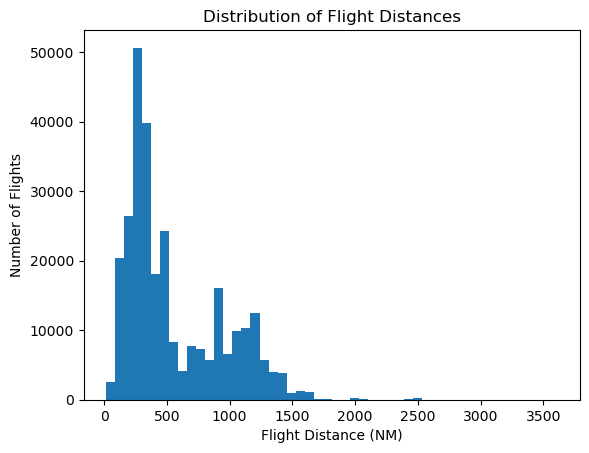

In [5]:
plt.hist(df["GroundDistance [NM]"], bins=50)
plt.xlabel("Flight Distance (NM)")
plt.ylabel("Number of Flights")
plt.title("Distribution of Flight Distances")
plt.show()

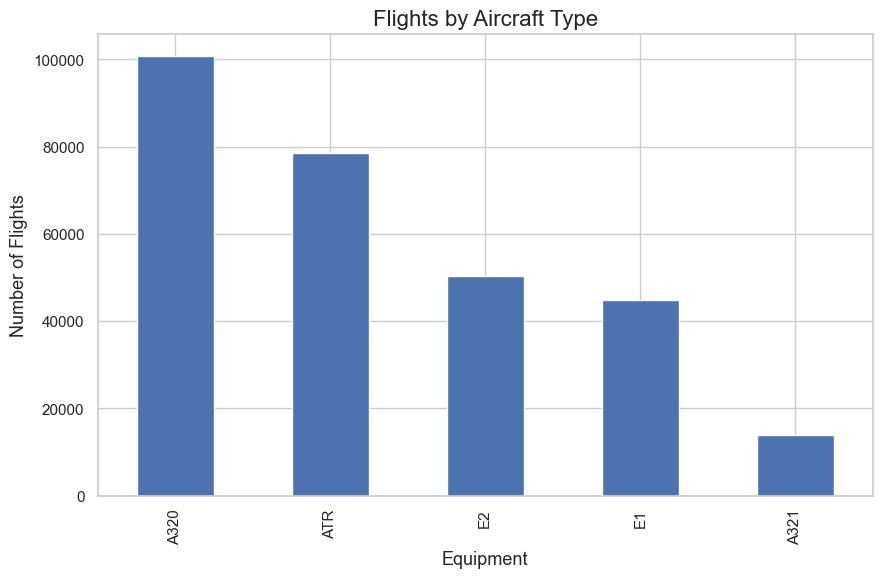

In [8]:
fleet_counts = df["Equipment"].value_counts()

fleet_counts.plot(kind="bar")
plt.title("Flights by Aircraft Type")
plt.ylabel("Number of Flights")
plt.show()

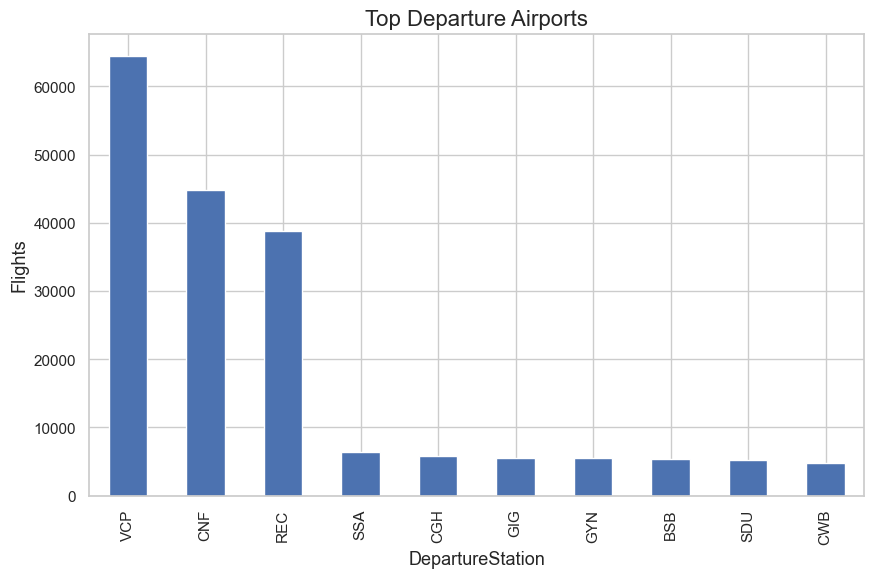

In [9]:
top_airports = df["DepartureStation"].value_counts().head(10)

top_airports.plot(kind="bar")
plt.title("Top Departure Airports")
plt.ylabel("Flights")
plt.show()

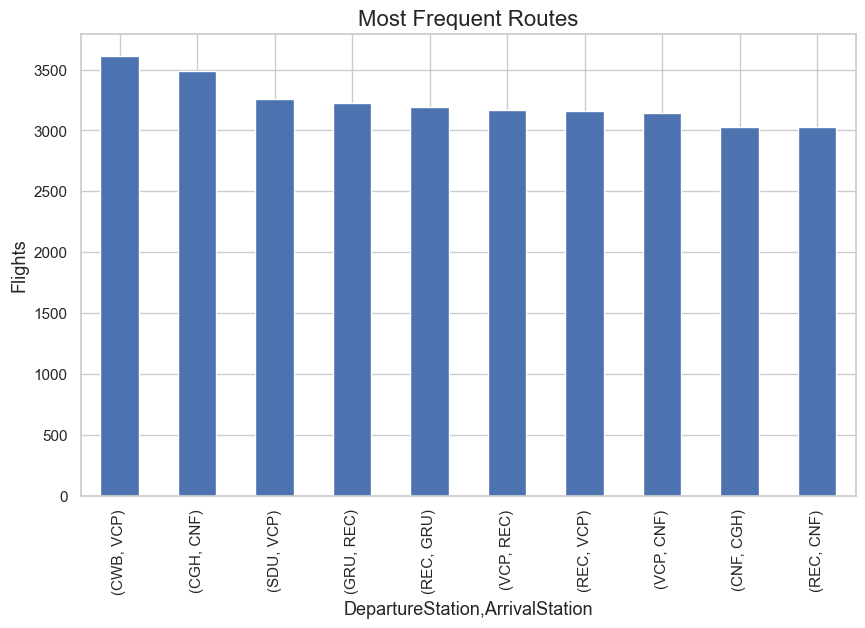

In [ ]:
routes = (
    df.groupby(["DepartureStation","ArrivalStation"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

routes.plot(kind="bar")
plt.title("Most Frequent Routes")
plt.ylabel("Flights")
df["Fuel_per_NM"] = df["TripFuelBurnTotal [KG]"] / df["GroundDistance [NM]"]plt.show()

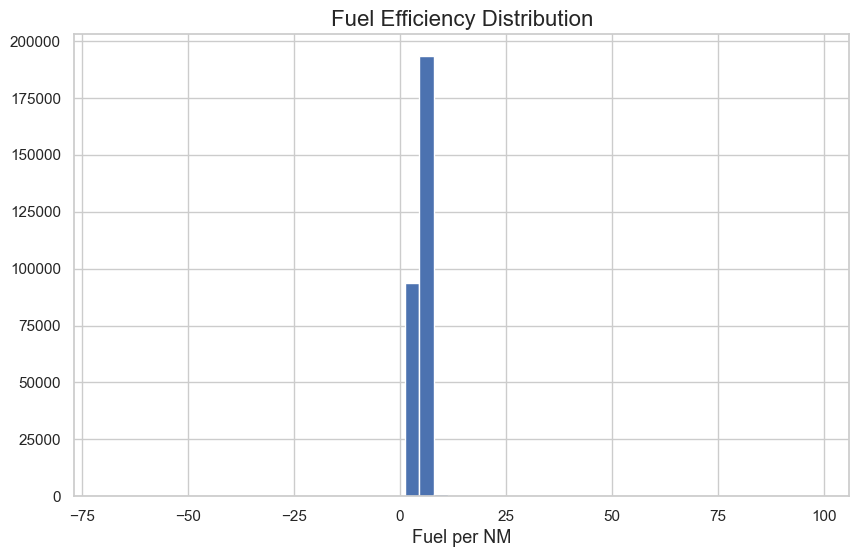

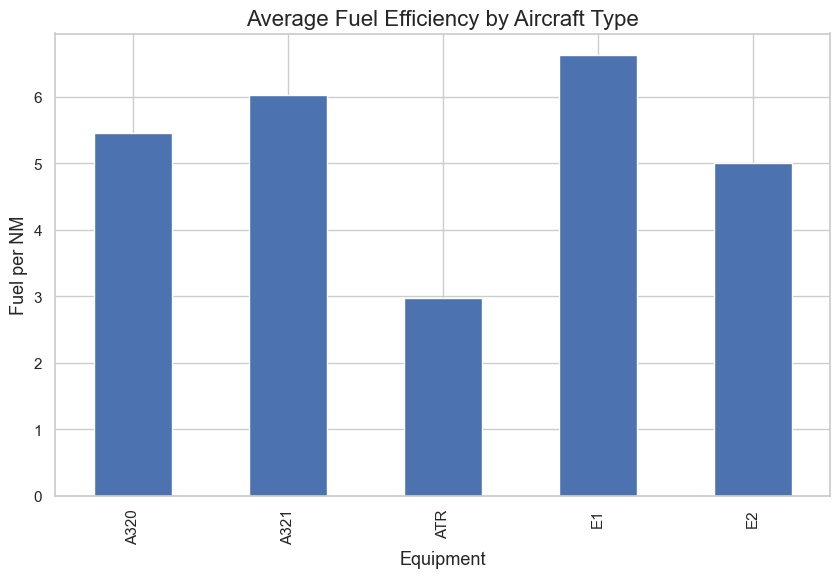

In [12]:
df["Fuel_per_NM"] = df["TripFuelBurnTotal [KG]"] / df["GroundDistance [NM]"]

plt.hist(df["Fuel_per_NM"], bins=50)
plt.xlabel("Fuel per NM")
plt.title("Fuel Efficiency Distribution")
plt.show()

eff = df.groupby("Equipment")["Fuel_per_NM"].mean()

eff.plot(kind="bar")
plt.title("Average Fuel Efficiency by Aircraft Type")
plt.ylabel("Fuel per NM")
plt.show()

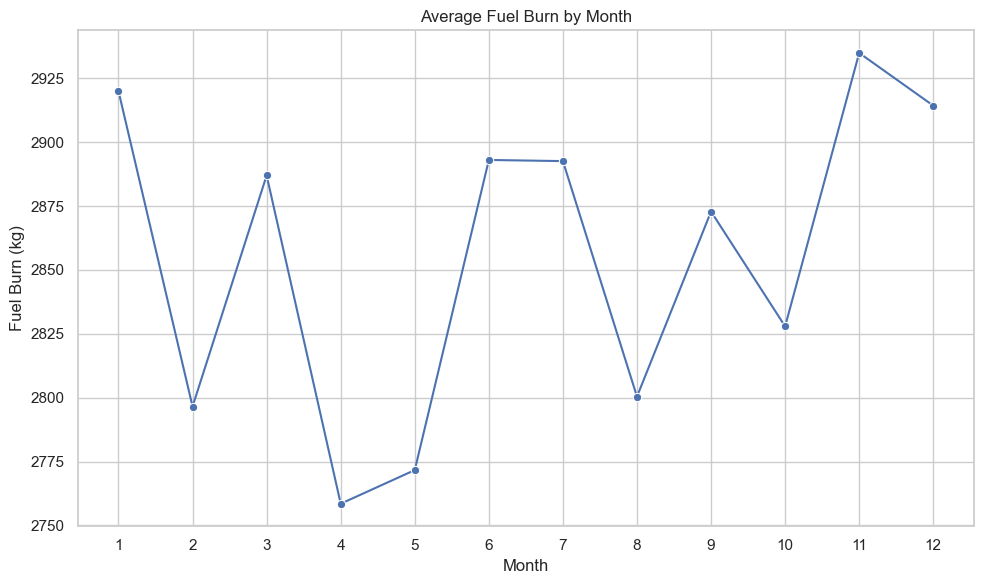

In [16]:
route_eff = (
    df.groupby(["DepartureStation","ArrivalStation"])["Fuel_per_NM"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

df["STDUTC"] = pd.to_datetime(df["STDUTC"])
df["Month"] = df["STDUTC"].dt.month
monthly = df.groupby("Month")["TripFuelBurnTotal [KG]"].mean()

sns.set_theme(style="whitegrid")

plt.figure()

sns.lineplot(x=monthly.index, y=monthly.values, marker="o")

plt.title("Average Fuel Burn by Month")
plt.xlabel("Month")
plt.ylabel("Fuel Burn (kg)")

plt.xticks(range(1,13))

plt.tight_layout()
plt.show()


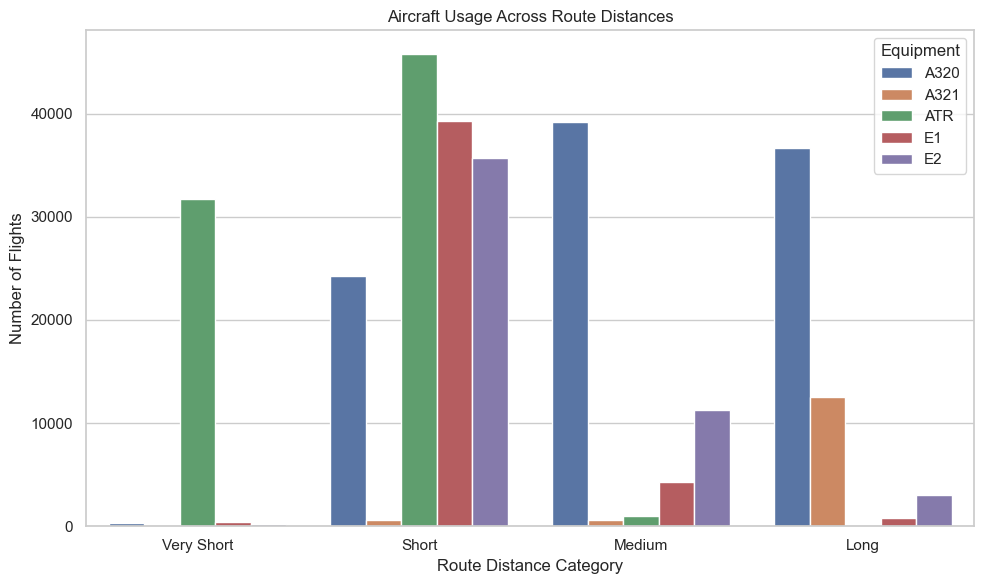

In [17]:
df["DistanceCategory"] = pd.cut(
    df["GroundDistance [NM]"],
    bins=[0,200,500,1000,2000],
    labels=["Very Short","Short","Medium","Long"]
)
distance_usage = (
    df.groupby(["DistanceCategory","Equipment"])
    .size()
    .reset_index(name="Flights")
)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.barplot(
    data=distance_usage,
    x="DistanceCategory",
    y="Flights",
    hue="Equipment"
)

plt.title("Aircraft Usage Across Route Distances")
plt.xlabel("Route Distance Category")
plt.ylabel("Number of Flights")

plt.tight_layout()
plt.show()